# Assignment 4 — How Few Components Can You Get Away With?
**Feature Engineering & MLOps · PCA Practical**

Dataset: `pca_regression_data.csv` — 800 rows, 60 numeric features, continuous target `score`.

## Setup

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

RANDOM_STATE = 42

df = pd.read_csv('pca_regression_data.csv')  # place file in same folder as this notebook
feature_cols = [c for c in df.columns if c.startswith('feature_')]
X = df[feature_cols].values
y = df['score'].values
print(df.shape, len(feature_cols), "features")


(800, 62) 60 features


## 4.1 — Baseline: all 60 raw features

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on TRAIN only
X_test_scaled = scaler.transform(X_test)

lr_baseline = LinearRegression()
lr_baseline.fit(X_train_scaled, y_train)
baseline_r2 = r2_score(y_test, lr_baseline.predict(X_test_scaled))

print(f"Baseline test R2 (all 60 features): {baseline_r2:.4f}")


Baseline test R2 (all 60 features): 0.8584


## 4.2 — PCA: explained variance and the scree plot

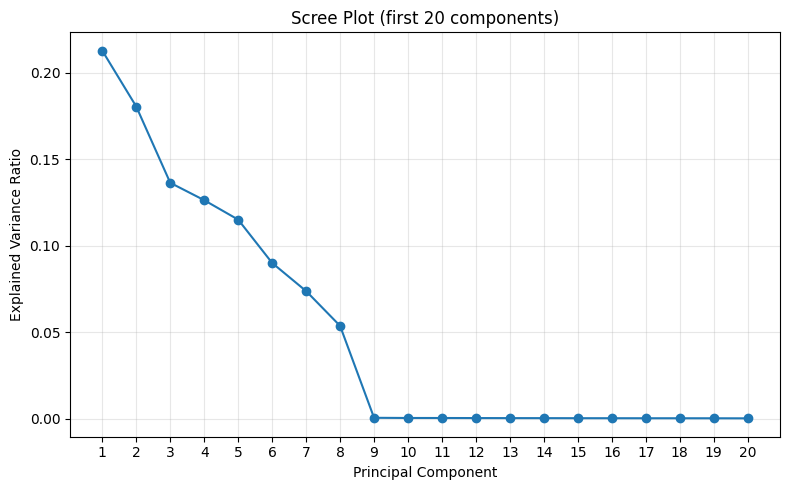

In [3]:
pca_full = PCA()
pca_full.fit(X_train_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

plt.figure(figsize=(8,5))
n_show = 20
plt.plot(range(1, n_show+1), evr[:n_show], marker='o')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Scree Plot (first 20 components)')
plt.xticks(range(1, n_show+1))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


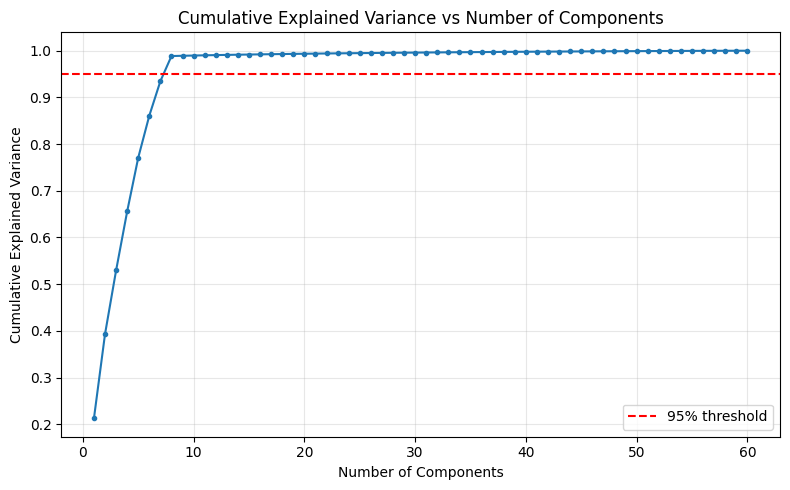

In [4]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_evr)+1), cum_evr, marker='o', markersize=3)
plt.axhline(0.95, color='red', linestyle='--', label='95% threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Cumulative Explained Variance vs Number of Components')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**My visual elbow estimate (written down BEFORE Section 4.3):**

> I estimate the elbow to be around **8 components**. The explained variance ratio decreases substantially from component 1 through component 8, and after component 8 the remaining components contribute only a very small amount of variance. This suggests that most of the meaningful variation is captured by the first 8 principal components.

## 4.3 — Find the smallest component count that matches baseline accuracy

In [5]:
component_counts = [2, 4, 6, 8, 10, 12, 15, 20, 30, 40]
results = []

for n in component_counts:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    lr = LinearRegression().fit(X_train_pca, y_train)
    r2 = r2_score(y_test, lr.predict(X_test_pca))
    results.append((n, r2))
    print(f"n_components={n:2d}  test R2={r2:.4f}  diff vs baseline={r2-baseline_r2:+.4f}")


n_components= 2  test R2=0.2409  diff vs baseline=-0.6174
n_components= 4  test R2=0.4989  diff vs baseline=-0.3595
n_components= 6  test R2=0.6946  diff vs baseline=-0.1638
n_components= 8  test R2=0.8716  diff vs baseline=+0.0132
n_components=10  test R2=0.8722  diff vs baseline=+0.0139
n_components=12  test R2=0.8718  diff vs baseline=+0.0134
n_components=15  test R2=0.8724  diff vs baseline=+0.0140
n_components=20  test R2=0.8725  diff vs baseline=+0.0142
n_components=30  test R2=0.8665  diff vs baseline=+0.0081
n_components=40  test R2=0.8634  diff vs baseline=+0.0050


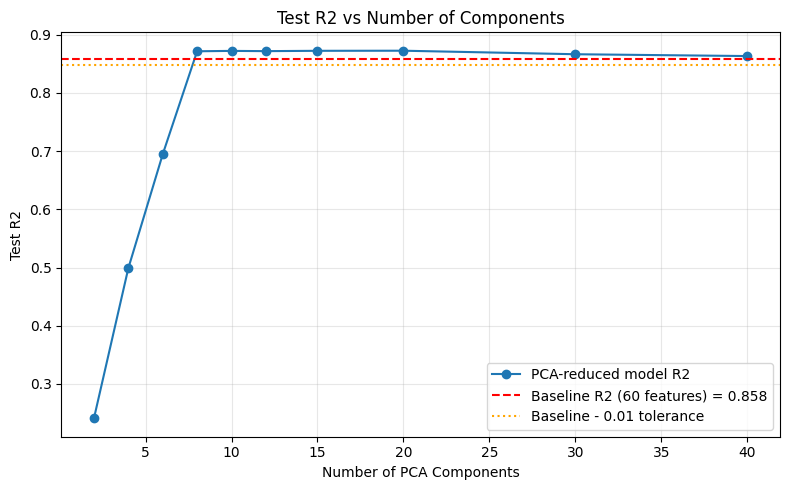

In [6]:
ns = [r[0] for r in results]
r2s = [r[1] for r in results]

plt.figure(figsize=(8,5))
plt.plot(ns, r2s, marker='o', label='PCA-reduced model R2')
plt.axhline(baseline_r2, color='red', linestyle='--', label=f'Baseline R2 (60 features) = {baseline_r2:.3f}')
plt.axhline(baseline_r2 - 0.01, color='orange', linestyle=':', label='Baseline - 0.01 tolerance')
plt.xlabel('Number of PCA Components')
plt.ylabel('Test R2')
plt.title('Test R2 vs Number of Components')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [7]:
smallest_n = next(n for n, r2 in results if r2 >= baseline_r2 - 0.01)
print(f"Smallest number of components within 0.01 of baseline R2: {smallest_n}")


Smallest number of components within 0.01 of baseline R2: 8


**Did the smallest matching component count agree with my Section 4.2 visual elbow estimate?**

> **Yes.** My visual elbow estimate was around **8 components**, and Section 4.3 found that **8 components** is the smallest tested count within 0.01 of the baseline. The 8-component model achieved a test R² of **0.8716**, compared with the all-60-feature baseline of **0.8584**, so it actually exceeded the baseline by **0.0132**.

## 4.4 — Explain it

Write 4-6 sentences here using YOUR OWN numbers from the cells above. Cover: (1) how many components matched/beat the 60-feature baseline, (2) roughly what fraction of variance those components captured, (3) what that implies about how many independent 'true' signals are actually driving the 60 observed features, and (4) why reducing dimensionality can sometimes *improve* test R2 rather than just make the model smaller (think noise vs. signal, and overfitting on 60 correlated/noisy raw columns vs. a handful of clean latent axes).

> The Linear Regression baseline using all 60 standardized features achieved a test R² of **0.8584**. Using only **8 principal components** increased the test R² to **0.8716**, which is **0.0132 higher** than the baseline. These 8 components capture about **98.86% of the total variance** in the training data, showing that the 60 original features contain substantial redundancy and that most of their useful information can be represented by a much smaller set of underlying latent signals. This suggests that the effective dimensionality of the dataset is much lower than 60, with many observed features being correlated or driven by common factors. PCA can improve test R² because it concentrates the important signal into a few orthogonal components while reducing the influence of low-variance/noisy directions, which can help the linear model generalize better.

## Bonus — RandomForestRegressor comparison (optional, +10%)

In [8]:
rf_baseline = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
rf_baseline.fit(X_train_scaled, y_train)
rf_baseline_r2 = r2_score(y_test, rf_baseline.predict(X_test_scaled))
print(f"RF baseline (60 features) test R2: {rf_baseline_r2:.4f}")

for n in component_counts:
    pca = PCA(n_components=n)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)
    rf = RandomForestRegressor(random_state=RANDOM_STATE, n_estimators=300)
    rf.fit(X_train_pca, y_train)
    r2 = r2_score(y_test, rf.predict(X_test_pca))
    print(f"n_components={n:2d}  RF test R2={r2:.4f}  diff vs RF baseline={r2-rf_baseline_r2:+.4f}")


RF baseline (60 features) test R2: 0.8002


n_components= 2  RF test R2=0.1643  diff vs RF baseline=-0.6358


n_components= 4  RF test R2=0.4185  diff vs RF baseline=-0.3817


n_components= 6  RF test R2=0.6074  diff vs RF baseline=-0.1928


n_components= 8  RF test R2=0.7427  diff vs RF baseline=-0.0575


...

n_components=12  RF test R2=0.7247  diff vs RF baseline=-0.0754


n_components=15  RF test R2=0.7164  diff vs RF baseline=-0.0837


n_components=20  RF test R2=0.7038  diff vs RF baseline=-0.0964


n_components=30  RF test R2=0.6843  diff vs RF baseline=-0.1158


n_components=40  RF test R2=0.6661  diff vs RF baseline=-0.1341


**Does the same number of components match RF baseline accuracy? Why might that differ from linear regression?**

> **No.** The Random Forest baseline with all 60 features achieved a test R² of **0.8002**, while the best PCA result among the tested component counts was **0.7427 at 8 components**, which is still **0.0575 below** the baseline. Therefore, none of the tested component counts came within 0.01 of the RF baseline. This can happen because Random Forests make splits using individual feature values, whereas PCA replaces the original features with linear combinations of many features. Those combinations can make the information less directly accessible to tree splits, so dimensionality reduction that helps a linear model does not necessarily help a tree-based model.